<a href="https://colab.research.google.com/github/aliiiafzal/Appliance-Energy-Use-Prediction/blob/main/Dissertation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>> Please choose your energydata_complete.csv file ...


Saving energydata_complete.csv to energydata_complete.csv
[load] 19735 rows x 29 cols | 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
[quality] no missing, no duplicates, regular 10-min sampling -> OK
[feat] dropped rv2 (exact duplicate of rv1); rv1 kept as noise probe
[feat] added calendar + cyclical time features
[feat] added lag + rolling features -> 19723 rows after dropping warm-up
[feat] 42 model features
[split] train 13806 rows | 2016-01-11 19:00:00 -> 2016-04-16 15:50:00
[split] val    2958 rows | 2016-04-16 16:00:00 -> 2016-05-07 04:50:00
[split] test   2959 rows | 2016-05-07 05:00:00 -> 2016-05-27 18:00:00
[scale] StandardScaler fit on train only -> val/test transformed


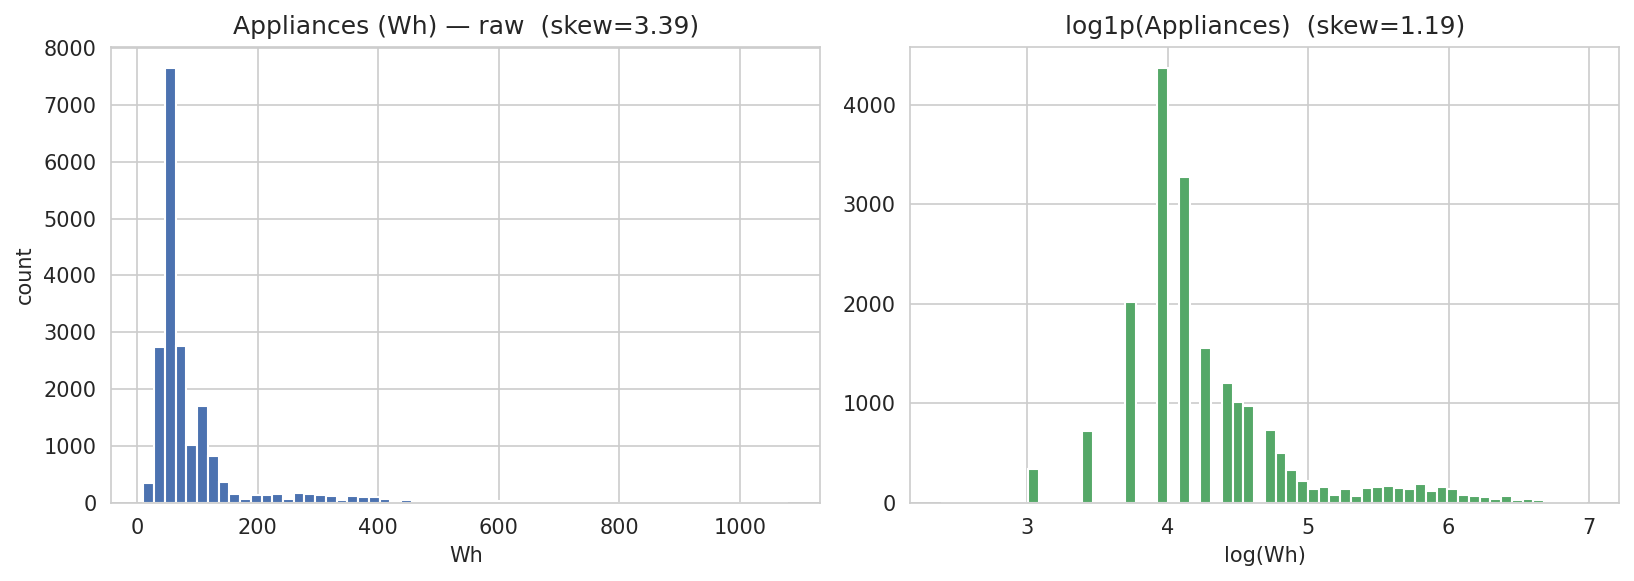

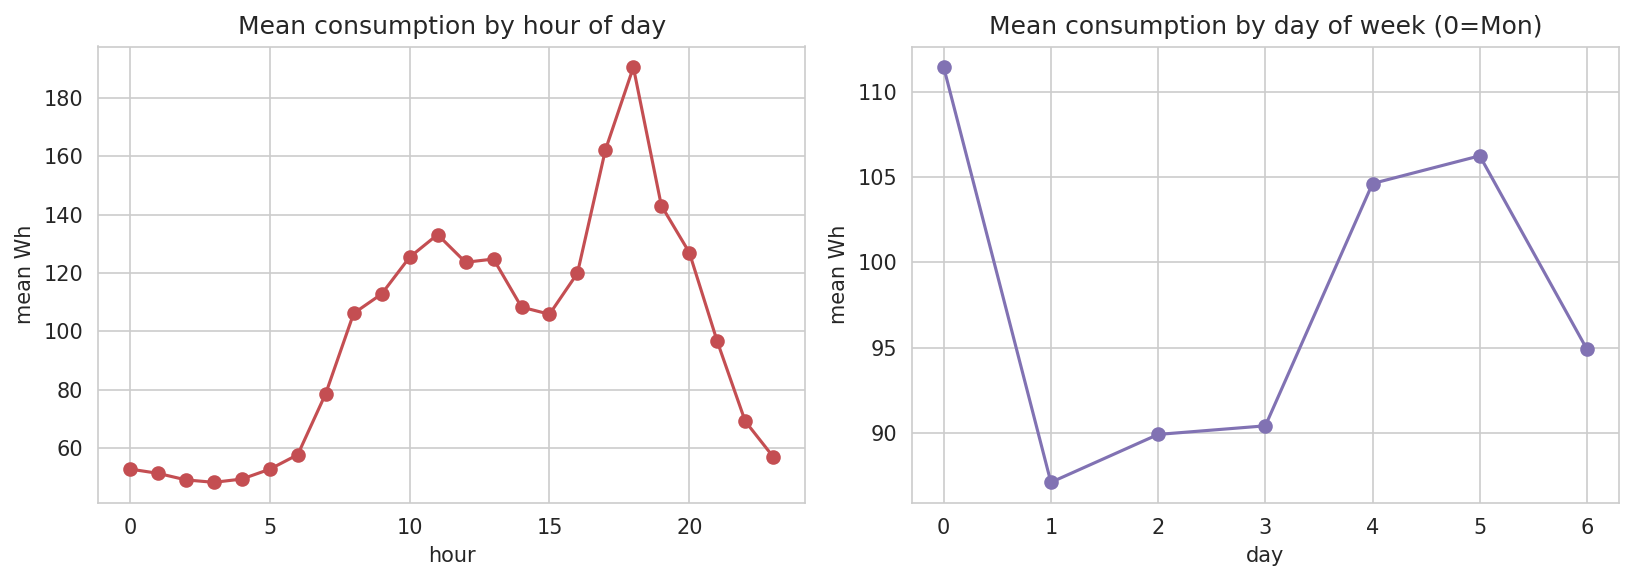

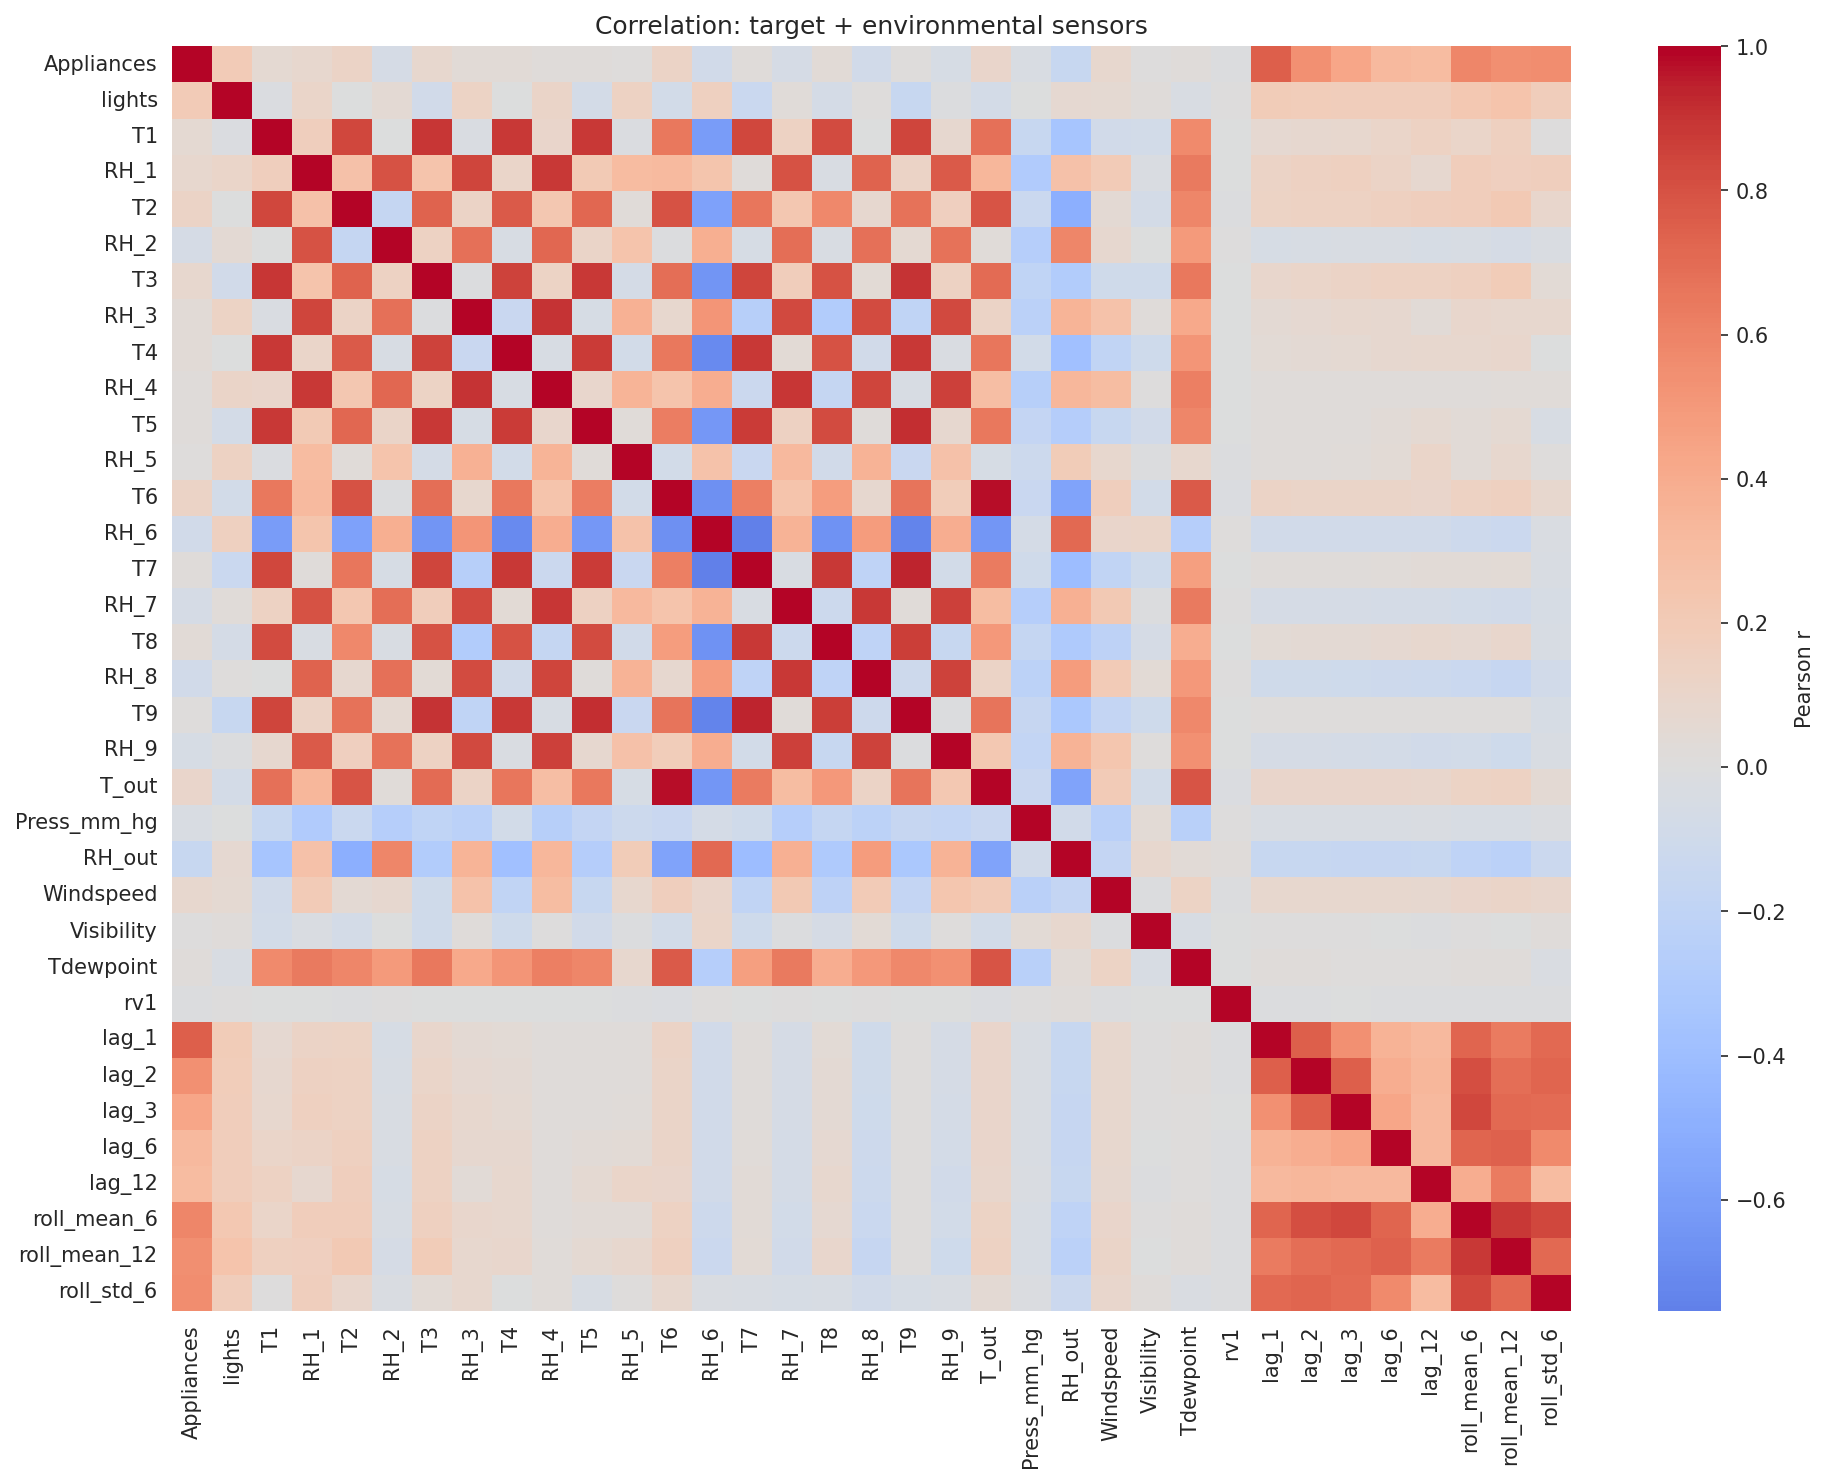

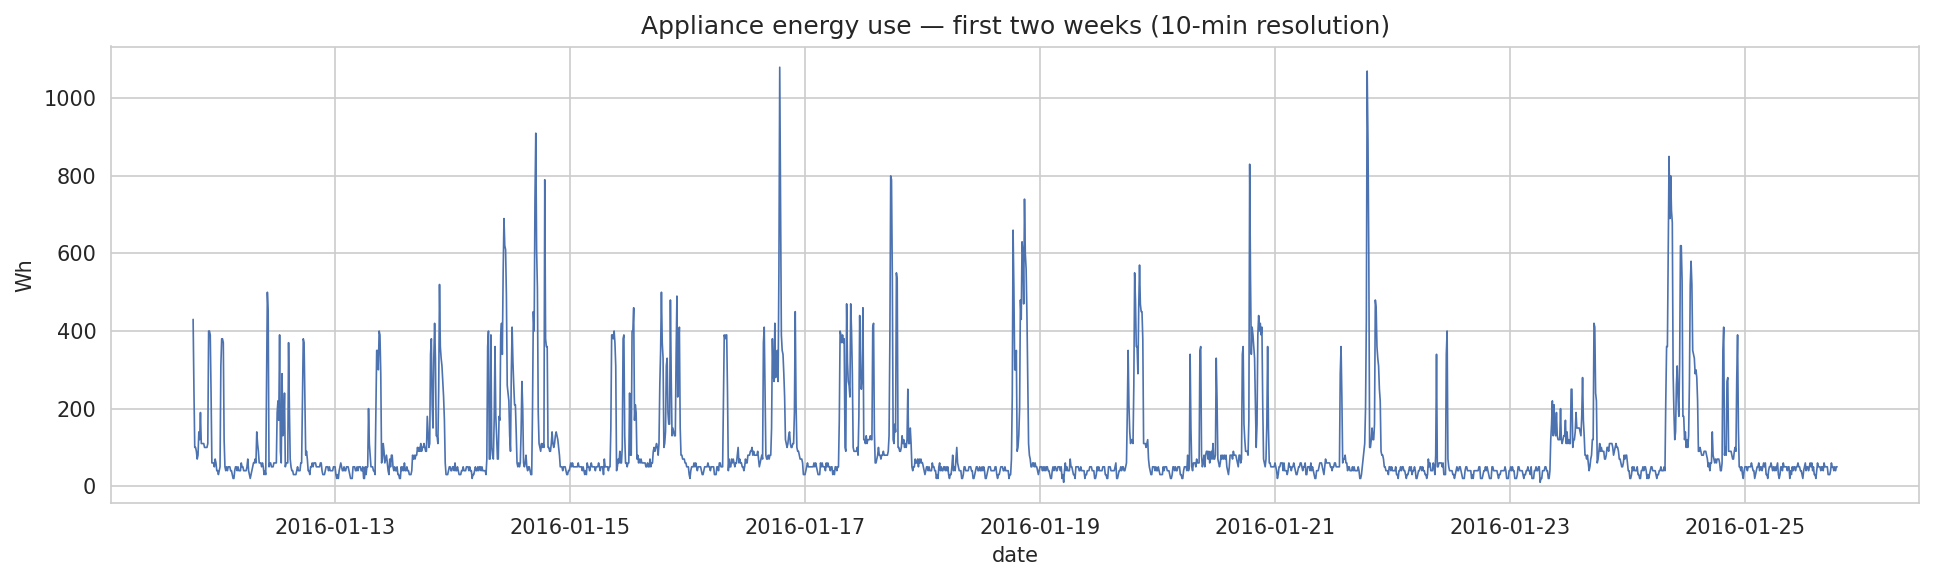

[figs] 4 EDA figures saved and displayed
[seq] demo sequence shape (13782, 24, 42)  (samples, lookback, features)
[save] train/val/test CSVs + scaler + meta.json written


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> phase1_outputs.zip is downloading.

PHASE 1 COMPLETE.


In [ ]:
"""
============================================================================
 PHASE 1: DATA ENGINEERING
 Appliance Energy Use Prediction  |  MSc AI Dissertation, Univ. of Stirling
 Author: Ali Afzal
----------------------------------------------------------------------------
 PURPOSE
   Implements Objective 4.2.1 (Data Engineering) of the research proposal:
   clean, normalise and transform the Appliances Energy Prediction dataset
   into a form suitable for BOTH static models (Random Forest, XGBoost) and
   a sequential model (LSTM). Supports RQ1 and RQ2.

============================================================================
"""

import os
import json
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Helper that reliably shows a saved figure inside the Colab notebook. It
# embeds the saved PNG directly into the cell output, so the image always
# appears regardless of the matplotlib backend.
def show_image(path):
    try:
        from IPython.display import Image, display
        display(Image(filename=path))
    except Exception:
        pass  # outside a notebook (e.g. plain Python) -> just skip the display


# Reproducibility: a fixed seed is set so every run gives the same result,
# which the proposal relies on for a fair, repeatable model comparison.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")


# ---------------------------------------------------------------------------
# 0. UPLOAD THE DATASET  (Colab file picker)
#    Dataset: the Appliances Energy Prediction dataset — about 4.5 months of
#    10-minute readings: appliance energy use (Wh), indoor temperature and
#    humidity from a wireless sensor network, and outdoor weather variables.
# ---------------------------------------------------------------------------
try:
    from google.colab import files
    print(">> Please choose your energydata_complete.csv file ...")
    uploaded = files.upload()                 # opens the chooser
    IN_PATH = list(uploaded.keys())[0]        # name of the chosen file
except Exception:
    IN_PATH = "energydata_complete.csv"       # fallback when not on Colab

# Output folders for this phase's files.
PROJ = "energy_project"
DATA_DIR = f"{PROJ}/data"
FIG_DIR = f"{PROJ}/figures"
ART_DIR = f"{PROJ}/artifacts"

for d in (DATA_DIR, FIG_DIR, ART_DIR):
    os.makedirs(d, exist_ok=True)


# ===========================================================================
# 1. LOAD & ORDER
#    Energy use is a time series, so rows are sorted strictly by timestamp.
#    Correct ordering matters: the chronological split and the LSTM sequence
#    windows later both assume the rows are in time order.
# ===========================================================================
df = pd.read_csv(IN_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"[load] {df.shape[0]} rows x {df.shape[1]} cols | {df.date.min()} -> {df.date.max()}")

# Data-quality audit (reported in the Methodology chapter). The dataset is
# already well curated; here we confirm that rather than assume it.
assert df.isna().sum().sum() == 0,  "unexpected missing values"
assert df.duplicated().sum() == 0,  "unexpected duplicate rows"

interval = df.date.diff().dropna().dt.total_seconds().div(60)
assert interval.nunique() == 1 and interval.iloc[0] == 10, "irregular sampling"

print("[quality] no missing, no duplicates, regular 10-min sampling -> OK")


# ===========================================================================
# 2. FEATURE ENGINEERING
# ===========================================================================
# 2a. rv1 and rv2 are two random variables that the dataset authors
#     deliberately added to test whether a model can be fooled by irrelevant
#     inputs. They are an exact duplicate of each other here, so rv2 is dropped
#     and rv1 is kept as a "noise probe": in Phase 4, SHAP should rank rv1 near
#     zero, which is evidence that the models are not relying on noise.
assert (df["rv1"] == df["rv2"]).all(), "rv1/rv2 expected identical"
df = df.drop(columns=["rv2"])
print("[feat] dropped rv2 (exact duplicate of rv1); rv1 kept as noise probe")

# 2b. Calendar features from the timestamp.
#     Appliance use follows daily and weekly human routines, so hour-of-day
#     and day-of-week carry real signal.
#     The cyclical (sin/cos) encodings avoid the false jump from 23:00 to 00:00
#     and let the static models (RF/XGBoost) see time-of-day structure. This is
#     what makes RQ2 a fair test: we can then ask whether the LSTM captures
#     temporal dependencies BEYOND what these features already expose.
dt = df["date"].dt

df["hour"]       = dt.hour
df["dayofweek"]  = dt.dayofweek                # 0 = Monday
df["month"]      = dt.month
df["is_weekend"] = (dt.dayofweek >= 5).astype(int)

df["hour_sin"]   = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]   = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]    = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]    = np.cos(2 * np.pi * df["dayofweek"] / 7)

print("[feat] added calendar + cyclical time features")

# 2c. Lag and rolling-window features of the target. Appliance use is strongly
#     autocorrelated: the best single predictor of energy now is energy a few
#     minutes ago. These features give the STATIC tree models (RF/XGBoost)
#     access to that recent history. Crucially, every feature uses .shift() so
#     it only ever looks at PAST values — the current target never leaks in.
#     (The LSTM in Phase 3 instead learns this history directly from the raw
#     sequence, which is the heart of the RQ2 comparison.)
for L in [1, 2, 3, 6, 12]:                      # 10 min, 20 min, 30 min, 1 h, 2 h ago
    df[f"lag_{L}"] = df["Appliances"].shift(L)

df["roll_mean_6"]  = df["Appliances"].shift(1).rolling(6).mean()   # mean of last hour
df["roll_mean_12"] = df["Appliances"].shift(1).rolling(12).mean()  # mean of last 2 hours
df["roll_std_6"]   = df["Appliances"].shift(1).rolling(6).std()    # volatility, last hour

df = df.dropna().reset_index(drop=True)         # drop the first rows that have no history
print(f"[feat] added lag + rolling features -> {len(df)} rows after dropping warm-up")

# 2d. Target transform. The appliance load is bursty and heavily right-skewed
#     (skew ~3.4). Modelling log1p(Appliances) compresses that skew, stabilises
#     LSTM training, and reduces the influence of extreme spikes. All final
#     metrics (MAE/RMSE/R^2) are reported back on the ORIGINAL Wh scale via
#     expm1 in the later phases.
df["Appliances_log"] = np.log1p(df["Appliances"])

# Bookkeeping: which columns are model inputs vs targets.
TARGET_RAW = "Appliances"
TARGET_LOG = "Appliances_log"
feature_cols = [c for c in df.columns if c not in ["date", TARGET_RAW, TARGET_LOG]]

print(f"[feat] {len(feature_cols)} model features")


# ===========================================================================
# 3. CHRONOLOGICAL SPLIT 70 / 15 / 15
#    The data is split by time, never shuffled: training on the past and
#    testing on the future prevents look-ahead leakage and gives an honest
#    estimate of real forecasting performance on a held-out test set.
# ===========================================================================
n = len(df)
i_tr = int(n * 0.70)
i_va = int(n * 0.85)

train = df.iloc[:i_tr]
val   = df.iloc[i_tr:i_va]
test  = df.iloc[i_va:]

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"[split] {name:5} {len(part):5} rows | {part.date.min()} -> {part.date.max()}")


# ===========================================================================
# 4. SCALING
#    StandardScaler is fitted on the TRAINING data only, then applied to the
#    validation and test sets. Fitting on the whole dataset would leak future
#    statistics into training. Scaling matters most for the LSTM; it is
#    harmless for the tree models.
# ===========================================================================
x_scaler = StandardScaler()
x_scaler.fit(train[feature_cols])

def make_xy(part):
    """Scale features and return (X_scaled, y_log, y_raw) for one split."""
    X = pd.DataFrame(
        x_scaler.transform(part[feature_cols]),
        columns=feature_cols,
        index=part.index
    )
    return X, part[TARGET_LOG].values, part[TARGET_RAW].values

Xtr, ytr_log, ytr_raw = make_xy(train)
Xva, yva_log, yva_raw = make_xy(val)
Xte, yte_log, yte_raw = make_xy(test)

print("[scale] StandardScaler fit on train only -> val/test transformed")


# ===========================================================================
# 5. EDA FIGURES  (saved, then shown inline in the notebook)
# ===========================================================================

# Figure A — why we log-transform the target: raw skew vs. log skew.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df[TARGET_RAW], bins=60, color="#4C72B0")
ax[0].set(
    title=f"Appliances (Wh) — raw  (skew={df[TARGET_RAW].skew():.2f})",
    xlabel="Wh",
    ylabel="count"
)

ax[1].hist(df[TARGET_LOG], bins=60, color="#55A868")
ax[1].set(
    title=f"log1p(Appliances)  (skew={df[TARGET_LOG].skew():.2f})",
    xlabel="log(Wh)"
)

plt.tight_layout()
pathA = f"{FIG_DIR}/figA_target_distribution.png"
plt.savefig(pathA, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pathA)


# Figure B — the temporal signal: mean use by hour of day and by weekday.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

df.groupby("hour")[TARGET_RAW].mean().plot(ax=ax[0], marker="o", color="#C44E52")
ax[0].set(title="Mean consumption by hour of day", xlabel="hour", ylabel="mean Wh")

df.groupby("dayofweek")[TARGET_RAW].mean().plot(ax=ax[1], marker="o", color="#8172B3")
ax[1].set(title="Mean consumption by day of week (0=Mon)", xlabel="day", ylabel="mean Wh")

plt.tight_layout()
pathB = f"{FIG_DIR}/figB_temporal_profile.png"
plt.savefig(pathB, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pathB)


# Figure C — correlation of the target with the environmental sensors.
fig = plt.figure(figsize=(13, 10))
env_cols = [c for c in feature_cols if c not in [
    "hour", "dayofweek", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos"
]]

sns.heatmap(
    df[[TARGET_RAW] + env_cols].corr(),
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Pearson r"}
)

plt.title("Correlation: target + environmental sensors")
plt.tight_layout()
pathC = f"{FIG_DIR}/figC_correlation_heatmap.png"
plt.savefig(pathC, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pathC)


# Figure D — a two-week slice showing the bursty nature of appliance use.
fig = plt.figure(figsize=(13, 4))
two_wk = df[df.date < df.date.min() + pd.Timedelta(days=14)]

plt.plot(two_wk.date, two_wk[TARGET_RAW], lw=0.8, color="#4C72B0")
plt.title("Appliance energy use — first two weeks (10-min resolution)")
plt.xlabel("date")
plt.ylabel("Wh")

plt.tight_layout()
pathD = f"{FIG_DIR}/figD_timeseries_slice.png"
plt.savefig(pathD, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pathD)

print("[figs] 4 EDA figures saved and displayed")


# ===========================================================================
# 6. LSTM SEQUENCE BUILDER  (used in Phase 3)
#    Recurrent models such as the LSTM consume fixed-length windows of past
#    time steps rather than single rows. This helper turns the (rows, features)
#    matrix into (samples, lookback, features). lookback=24 -> the previous
#    24 x 10 min = 4 hours of context per prediction.
# ===========================================================================
def make_sequences(X2d, y1d, lookback=24):
    Xv = np.asarray(X2d)
    yv = np.asarray(y1d)

    Xs = []
    ys = []

    for i in range(lookback, len(Xv)):
        Xs.append(Xv[i - lookback : i])
        ys.append(yv[i])

    return np.asarray(Xs), np.asarray(ys)

demo_X, _ = make_sequences(Xtr.values, ytr_log, lookback=24)
print(f"[seq] demo sequence shape {demo_X.shape}  (samples, lookback, features)")


# ===========================================================================
# 7. SAVE + DOWNLOAD
#    Saving the processed splits, the fitted scaler, and the metadata means
#    every later phase loads identical data — needed for a fair, reproducible
#    model comparison.
# ===========================================================================
splits = [
    ("train", Xtr, ytr_log, ytr_raw),
    ("val",   Xva, yva_log, yva_raw),
    ("test",  Xte, yte_log, yte_raw)
]

for name, X, yl, yr in splits:
    out = X.copy()
    out[TARGET_LOG] = yl
    out[TARGET_RAW] = yr
    out.to_csv(f"{DATA_DIR}/{name}.csv", index=False)

joblib.dump(x_scaler, f"{ART_DIR}/x_scaler.joblib")

metadata = {
    "feature_cols": feature_cols,
    "target_raw": TARGET_RAW,
    "target_log": TARGET_LOG,
    "lookback": 24,
    "seed": RANDOM_SEED,
    "split": {
        "train": len(train),
        "val": len(val),
        "test": len(test)
    }
}

with open(f"{ART_DIR}/meta.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("[save] train/val/test CSVs + scaler + meta.json written")


# Bundle and download everything (Colab).
shutil.make_archive("phase1_outputs", "zip", PROJ)
try:
    from google.colab import files
    files.download("phase1_outputs.zip")
    print(">> phase1_outputs.zip is downloading.")
except Exception:
    print(">> Outputs saved in the 'energy_project' folder.")

print("\nPHASE 1 COMPLETE.")

[load] train (13806, 42)  val (2958, 42)  test (2959, 42)
[baseline] mean and persistence baselines computed


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[RF] best params: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10}
[XGB] best params: {'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

================  PHASE 2 RESULTS (held-out test set)  ================
                      Test MAE (Wh)  Test RMSE (Wh)  Test R2
Mean baseline                52.834          90.917   -0.000
Persistence baseline         26.756          66.859    0.459
Random Forest                26.676          60.317    0.560
XGBoost                      25.426          59.201    0.576


,Test MAE (Wh),Test RMSE (Wh),Test R2
Mean baseline,52.834,90.917,-0.000
Persistence baseline,26.756,66.859,0.459
Random Forest,26.676,60.317,0.560
XGBoost,25.426,59.201,0.576


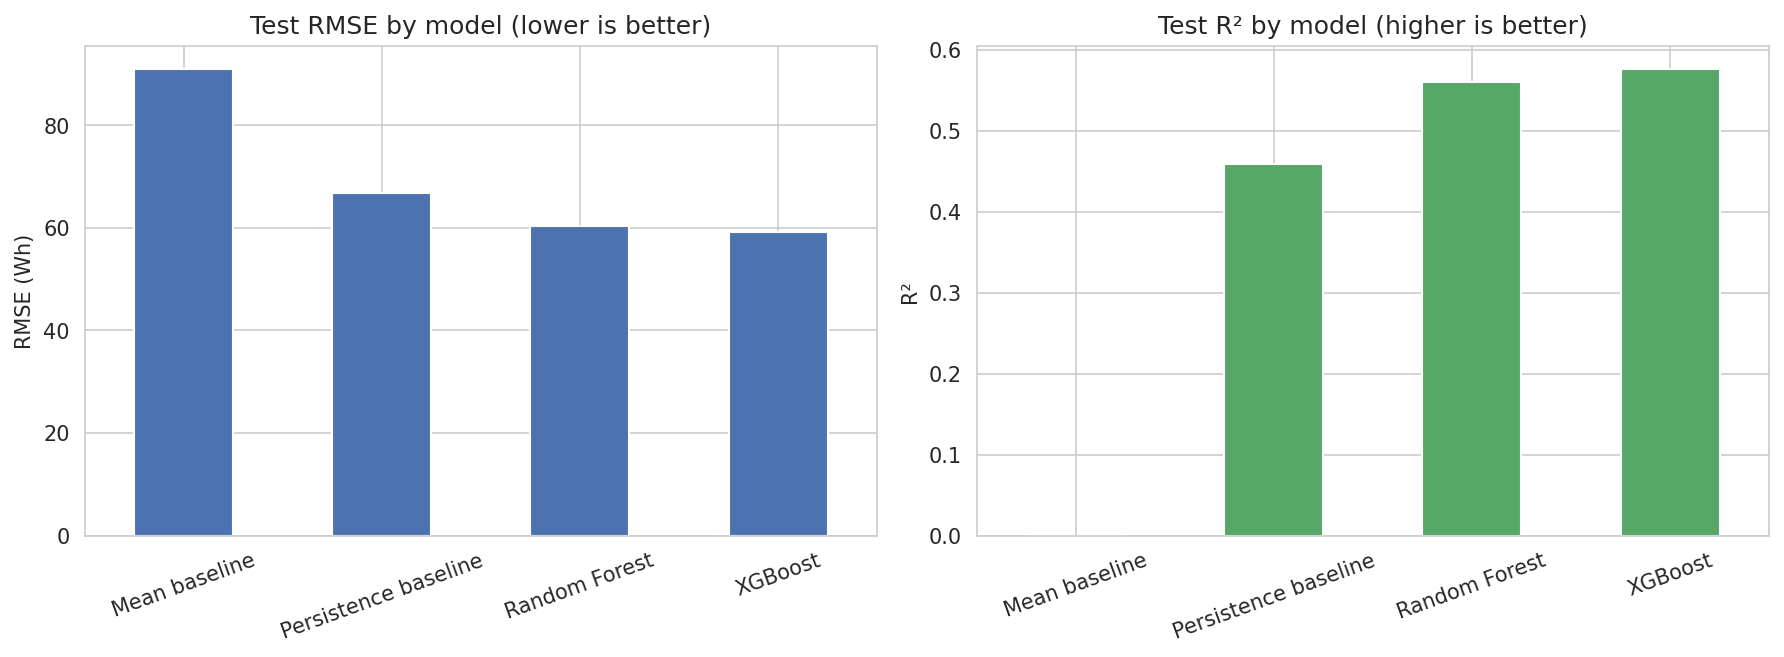

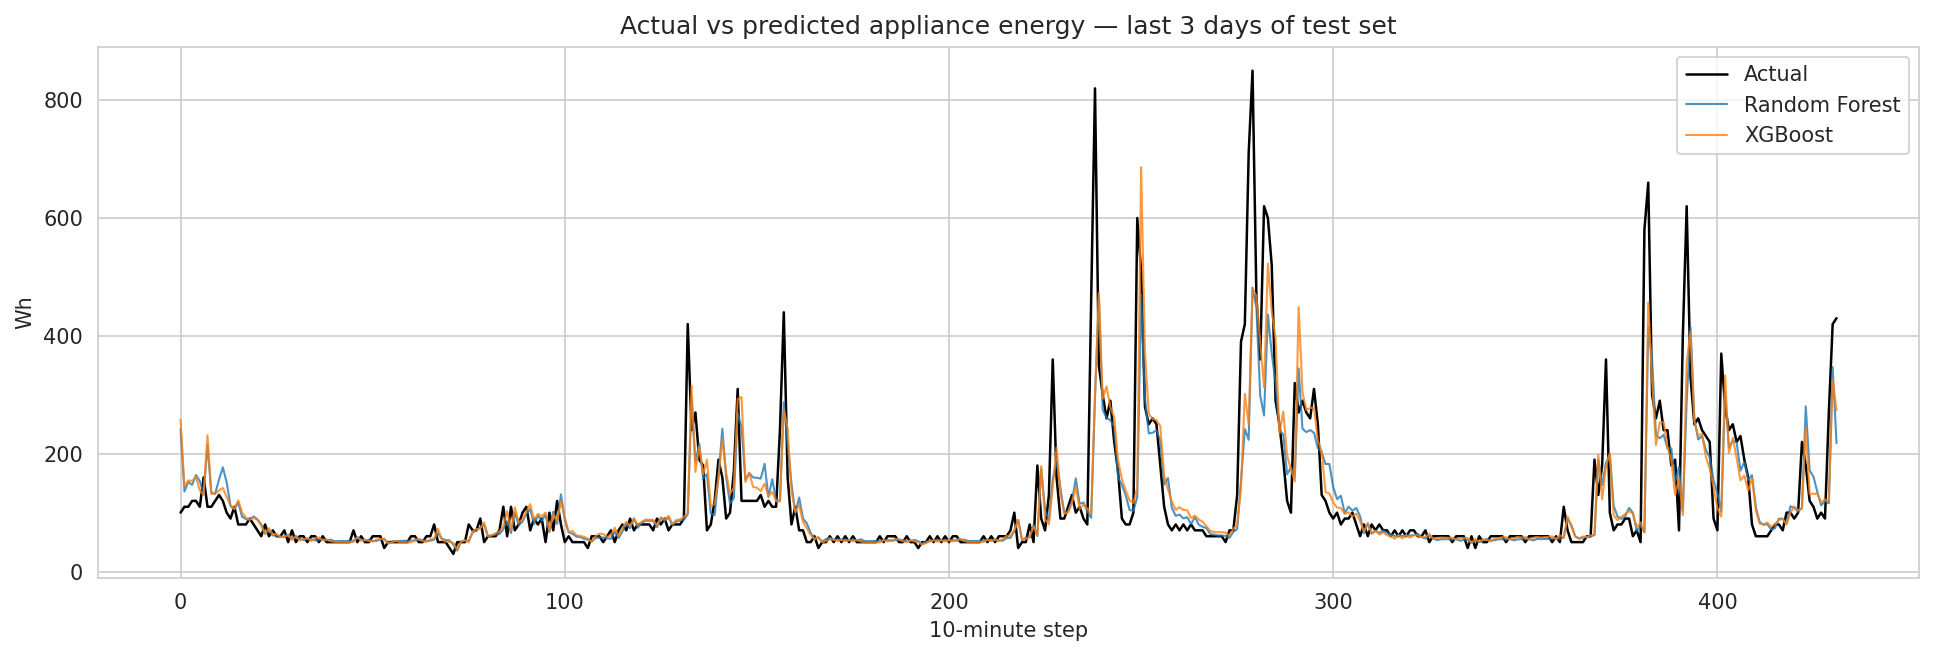

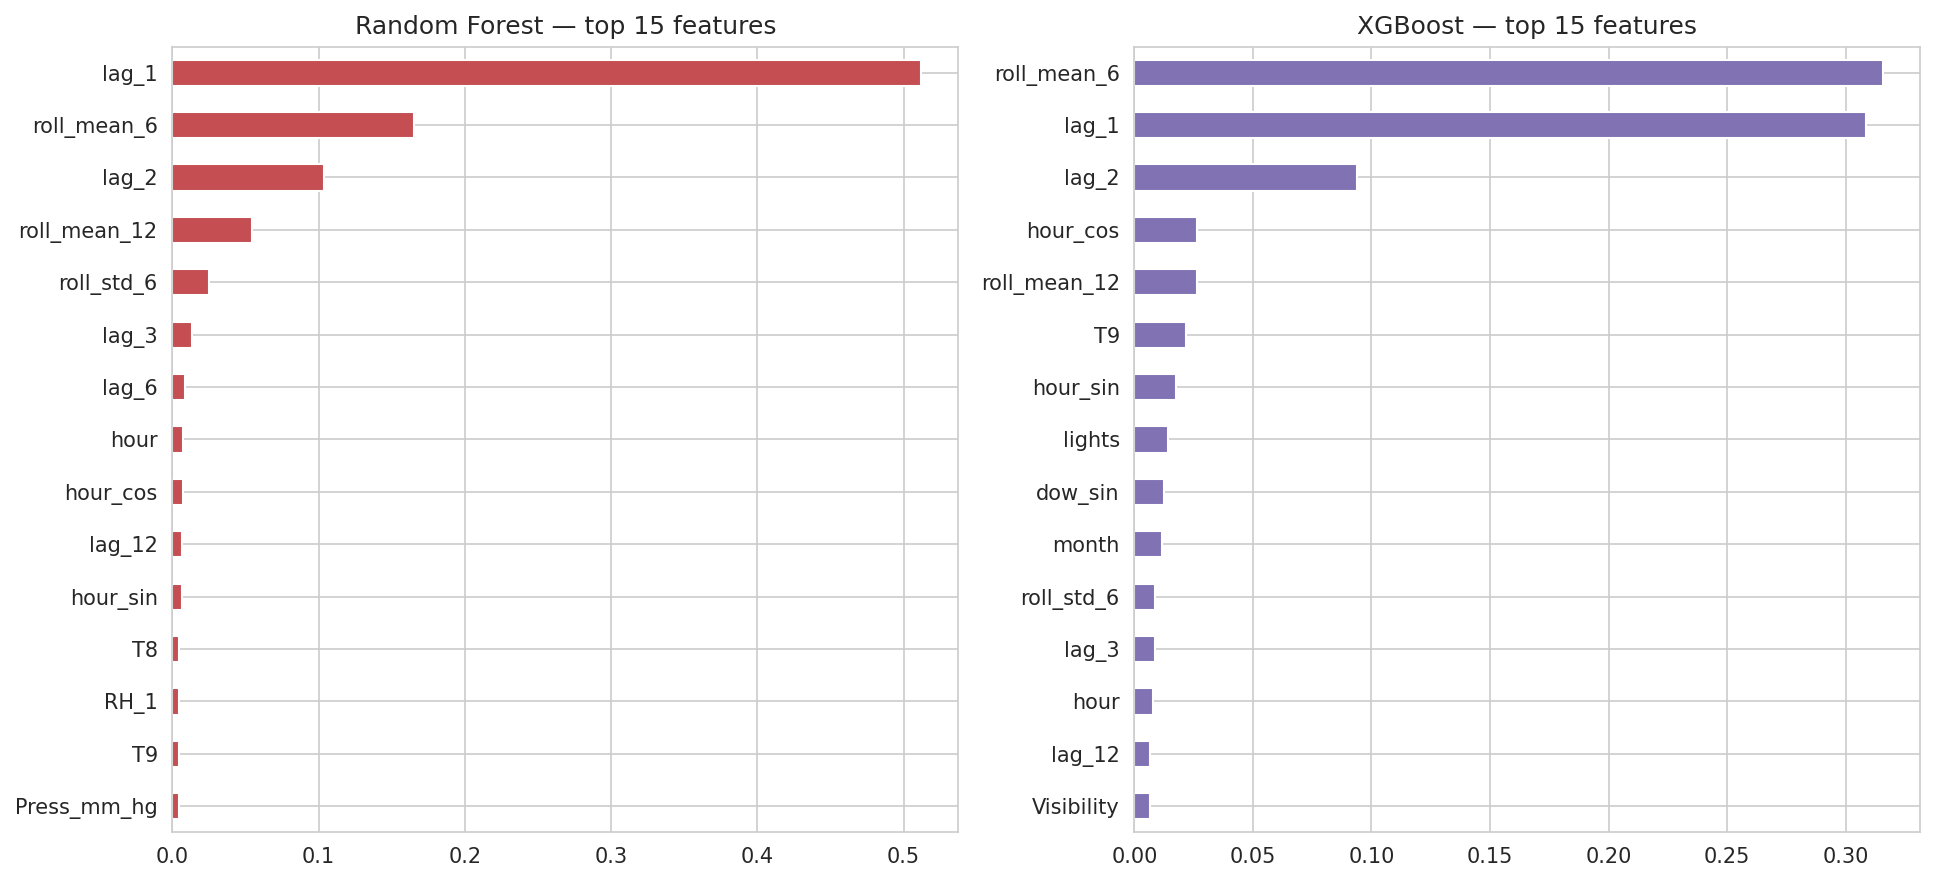

[figs] 3 result figures saved and displayed
[save] models + predictions + results table written


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> phase2_outputs.zip is downloading.

PHASE 2 COMPLETE.


In [ ]:
"""
============================================================================
 PHASE 2: BASELINE MODELS  —  GOOGLE COLAB VERSION
----------------------------------------------------------------------------
 PURPOSE
   Implements Objective 4.2.2 (the static models) of the research proposal:
   a naive baseline (the success floor), a tuned Random Forest, and a tuned
   XGBoost model. All three are evaluated on the held-out TEST set with MAE,
   RMSE and R^2 reported in real Wh. Supports RQ1 and RQ2 (the static side of
   the static-vs-sequential comparison; the LSTM is added in Phase 3).
----------------------------------------------------------------------------
============================================================================
"""

import os
import sys
import json
import joblib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost is pre-installed on Colab; install quietly if it is missing.
try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reusable helper: show a saved figure inline in the notebook.
def show_image(path):
    try:
        from IPython.display import Image, display
        display(Image(filename=path))
    except Exception:
        pass


SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")

PROJ = "energy_project"
DATA_DIR = f"{PROJ}/data"
FIG_DIR = f"{PROJ}/figures"
ART_DIR = f"{PROJ}/artifacts"


# ===========================================================================
# 0. LOAD PHASE 1 DATA
#    If the processed folder is missing (e.g. the runtime was reset), ask for
#    phase1_outputs.zip and unzip it so this phase is self-contained.
# ===========================================================================
if not os.path.exists(f"{DATA_DIR}/train.csv"):
    try:
        from google.colab import files
        print(">> Phase 1 data not found. Please upload phase1_outputs.zip ...")
        up = files.upload()
        with zipfile.ZipFile(list(up.keys())[0]) as z:
            z.extractall(PROJ)
    except Exception as e:
        raise FileNotFoundError(
            "Run the Phase 1 cell first, or upload phase1_outputs.zip"
        ) from e


with open(f"{ART_DIR}/meta.json", "r") as f:
    meta = json.load(f)

FEATURES   = meta["feature_cols"]
TARGET_LOG = meta["target_log"]      # what the models predict (log scale)
TARGET_RAW = meta["target_raw"]      # what we evaluate on (Wh)


def load_data(split):
    df = pd.read_csv(f"{DATA_DIR}/{split}.csv")
    return df[FEATURES], df[TARGET_LOG].values, df[TARGET_RAW].values


Xtr, ytr_log, ytr_raw = load_data("train")
Xva, yva_log, yva_raw = load_data("val")
Xte, yte_log, yte_raw = load_data("test")

print(f"[load] train {Xtr.shape}  val {Xva.shape}  test {Xte.shape}")


# ===========================================================================
# 1. EVALUATION HELPER
#    Models predict in LOG space; we convert back to Wh with expm1 and clip at
#    zero (energy cannot be negative), then score in the real unit the proposal
#    asks for. The naive baselines are already in Wh, so they skip the convert.
# ===========================================================================
def to_wh(pred_log):
    return np.clip(np.expm1(pred_log), 0, None)


def score(y_true_raw, y_pred_raw):
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = mean_squared_error(y_true_raw, y_pred_raw) ** 0.5
    r2   = r2_score(y_true_raw, y_pred_raw)
    return mae, rmse, r2


results = {}        # model name -> (MAE, RMSE, R2)
preds   = {}        # model name -> test predictions in Wh (for later plots)


# ===========================================================================
# 2. NAIVE BASELINES  (the floor the real models must beat — proposal 4.3.1)
# ===========================================================================

# 2a. Mean predictor: always predict the average appliance use seen in training.
mean_pred = np.full_like(yte_raw, fill_value=ytr_raw.mean(), dtype=float)
results["Mean baseline"] = score(yte_raw, mean_pred)
preds["Mean baseline"]   = mean_pred

# 2b. Persistence predictor: predict the previous 10-minute reading. This is a
#     strong, standard time-series baseline. For each test point we use the
#     actual value immediately before it in the full ordered series.
y_all = np.concatenate([ytr_raw, yva_raw, yte_raw])
test_start = len(ytr_raw) + len(yva_raw)
persist_pred = y_all[test_start - 1 : test_start - 1 + len(yte_raw)]

results["Persistence baseline"] = score(yte_raw, persist_pred)
preds["Persistence baseline"]   = persist_pred

print("[baseline] mean and persistence baselines computed")

# Cross-validation scheme reused for both tree models: expanding-window splits
# that respect time order (no future data leaks into a fold's training part).
tscv = TimeSeriesSplit(n_splits=5)


# ===========================================================================
# 3. RANDOM FOREST  (tuned with time-series CV)
# ===========================================================================
rf_space = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", 0.5, 1.0],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    rf_space,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

rf_search.fit(Xtr, ytr_log)
rf = rf_search.best_estimator_

results["Random Forest"] = score(yte_raw, to_wh(rf.predict(Xte)))
preds["Random Forest"]   = to_wh(rf.predict(Xte))

print(f"[RF] best params: {rf_search.best_params_}")


# ===========================================================================
# 4. XGBOOST  (tuned with time-series CV, then early-stopped on the val set)
# ===========================================================================
xgb_space = {
    "n_estimators":     [300, 600, 1000],
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "reg_lambda":       [1.0, 5.0, 10.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1, tree_method="hist"),
    xgb_space,
    n_iter=25,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

xgb_search.fit(Xtr, ytr_log)
best_xgb_params = xgb_search.best_params_
print(f"[XGB] best params: {best_xgb_params}")

# Refit the best configuration with early stopping on the validation set so the
# number of boosting rounds is chosen objectively (guards against overfitting).
xgb = XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1, tree_method="hist")

try:
    xgb.set_params(early_stopping_rounds=50, eval_metric="rmse")
    xgb.fit(Xtr, ytr_log, eval_set=[(Xva, yva_log)], verbose=False)
except TypeError:
    xgb.fit(Xtr, ytr_log)  # older xgboost: no early stopping

results["XGBoost"] = score(yte_raw, to_wh(xgb.predict(Xte)))
preds["XGBoost"]   = to_wh(xgb.predict(Xte))


# ===========================================================================
# 5. RESULTS TABLE
# ===========================================================================
res_df = pd.DataFrame(
    results,
    index=["Test MAE (Wh)", "Test RMSE (Wh)", "Test R2"]
).T.round(3)

res_df.to_csv(f"{ART_DIR}/phase2_results.csv")

print("\n================  PHASE 2 RESULTS (held-out test set)  ================")
print(res_df.to_string())

try:
    from IPython.display import display
    display(res_df)
except Exception:
    pass


# ===========================================================================
# 6. FIGURES  (saved + shown inline)
# ===========================================================================

# Figure E — test RMSE and R^2 across all models (lower RMSE / higher R2 = better)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

res_df["Test RMSE (Wh)"].plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Test RMSE by model (lower is better)", ylabel="RMSE (Wh)")
ax[0].tick_params(axis="x", rotation=20)

res_df["Test R2"].plot.bar(ax=ax[1], color="#55A868")
ax[1].set(title="Test R\u00b2 by model (higher is better)", ylabel="R\u00b2")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
pE = f"{FIG_DIR}/figE_model_comparison.png"
plt.savefig(pE, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pE)


# Figure F — actual vs predicted over the last ~3 days of the test set, so the
# reader can see how closely RF and XGBoost track real appliance use.
win = 432  # 432 x 10 min = 3 days
fig = plt.figure(figsize=(13, 4.5))

plt.plot(yte_raw[-win:], label="Actual", color="black", lw=1.2)
plt.plot(preds["Random Forest"][-win:], label="Random Forest", lw=1.0, alpha=0.8)
plt.plot(preds["XGBoost"][-win:],       label="XGBoost",       lw=1.0, alpha=0.8)

plt.title("Actual vs predicted appliance energy — last 3 days of test set")
plt.xlabel("10-minute step")
plt.ylabel("Wh")
plt.legend()

plt.tight_layout()
pF = f"{FIG_DIR}/figF_actual_vs_pred.png"
plt.savefig(pF, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pF)


# Figure G — built-in feature importances (a first look; SHAP follows in Phase 4)
imp_rf  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values().tail(15)
imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values().tail(15)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

imp_rf.plot.barh(ax=ax[0], color="#C44E52")
ax[0].set(title="Random Forest — top 15 features")

imp_xgb.plot.barh(ax=ax[1], color="#8172B3")
ax[1].set(title="XGBoost — top 15 features")

plt.tight_layout()
pG = f"{FIG_DIR}/figG_feature_importance.png"
plt.savefig(pG, dpi=150, bbox_inches="tight")
plt.close(fig)
show_image(pG)

print("[figs] 3 result figures saved and displayed")


# ===========================================================================
# 7. SAVE MODELS + PREDICTIONS  (used by Phase 3 comparison and Phase 4 SHAP)
# ===========================================================================
joblib.dump(rf,  f"{ART_DIR}/random_forest.joblib")
joblib.dump(xgb, f"{ART_DIR}/xgboost.joblib")

test_predictions_df = pd.DataFrame({
    "actual_Wh": yte_raw,
    "rf_pred_Wh": preds["Random Forest"],
    "xgb_pred_Wh": preds["XGBoost"]
})
test_predictions_df.to_csv(f"{ART_DIR}/phase2_test_predictions.csv", index=False)

print("[save] models + predictions + results table written")

# Bundle and download (Colab).
import shutil
shutil.make_archive("phase2_outputs", "zip", PROJ)

try:
    from google.colab import files
    files.download("phase2_outputs.zip")
    print(">> phase2_outputs.zip is downloading.")
except Exception:
    print(">> Outputs saved in the 'energy_project' folder.")

print("\nPHASE 2 COMPLETE.")

>> Phase 2 outputs not found. Please upload phase2_outputs.zip ...


Saving phase2_outputs.zip to phase2_outputs.zip
[load] full matrix (19723, 42) | splits: train 13806, val 2958, test 2959
[seq] train (13783, 24, 42)  val (2958, 24, 42)  test (2959, 24, 42)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,353 (157.63 KB)

 Trainable params: 40,353 (157.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 2.2494 - mae: 1.0190 - val_loss: 0.2742 - val_mae: 0.3595 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.4235 - mae: 0.4953 - val_loss: 0.2661 - val_mae: 0.3588 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3622 - mae: 0.4576 - val_loss: 0.2241 - val_mae: 0.3465 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.3248 - mae: 0.4323 - val_loss: 0.1449 - val_mae: 0.2529 - learning_rate: 0.0010
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.2913 - mae: 0.4078 - val_loss: 0.3802 - val_mae: 0.3410 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2731 - mae: 0.3925 - val_loss: 0.1312 - val_mae: 0.2432 - learning_rate: 0.0010
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.2551 - mae: 0.3778 - val_loss: 0.1465 - val_mae: 0.2682 - learning_rate:

,Test MAE (Wh),Test RMSE (Wh),Test R2
Mean baseline,52.834,90.917,-0.000
Persistence baseline,26.756,66.859,0.459
Random Forest,26.676,60.317,0.560
XGBoost,25.426,59.201,0.576
LSTM,25.642,66.055,0.472


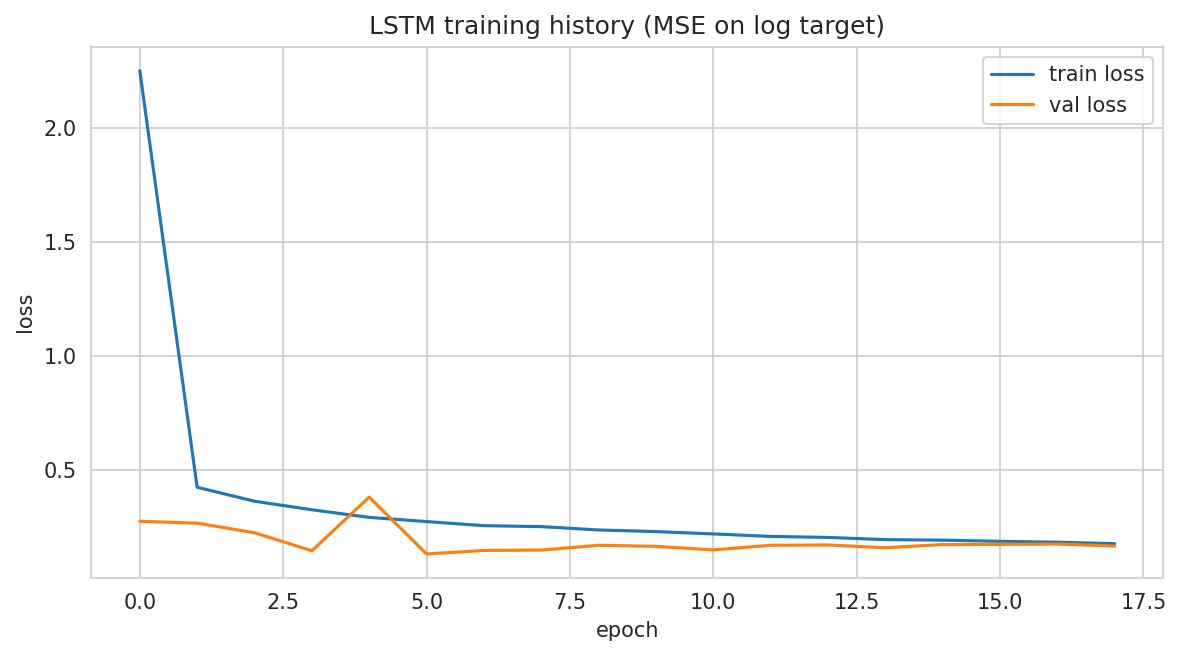

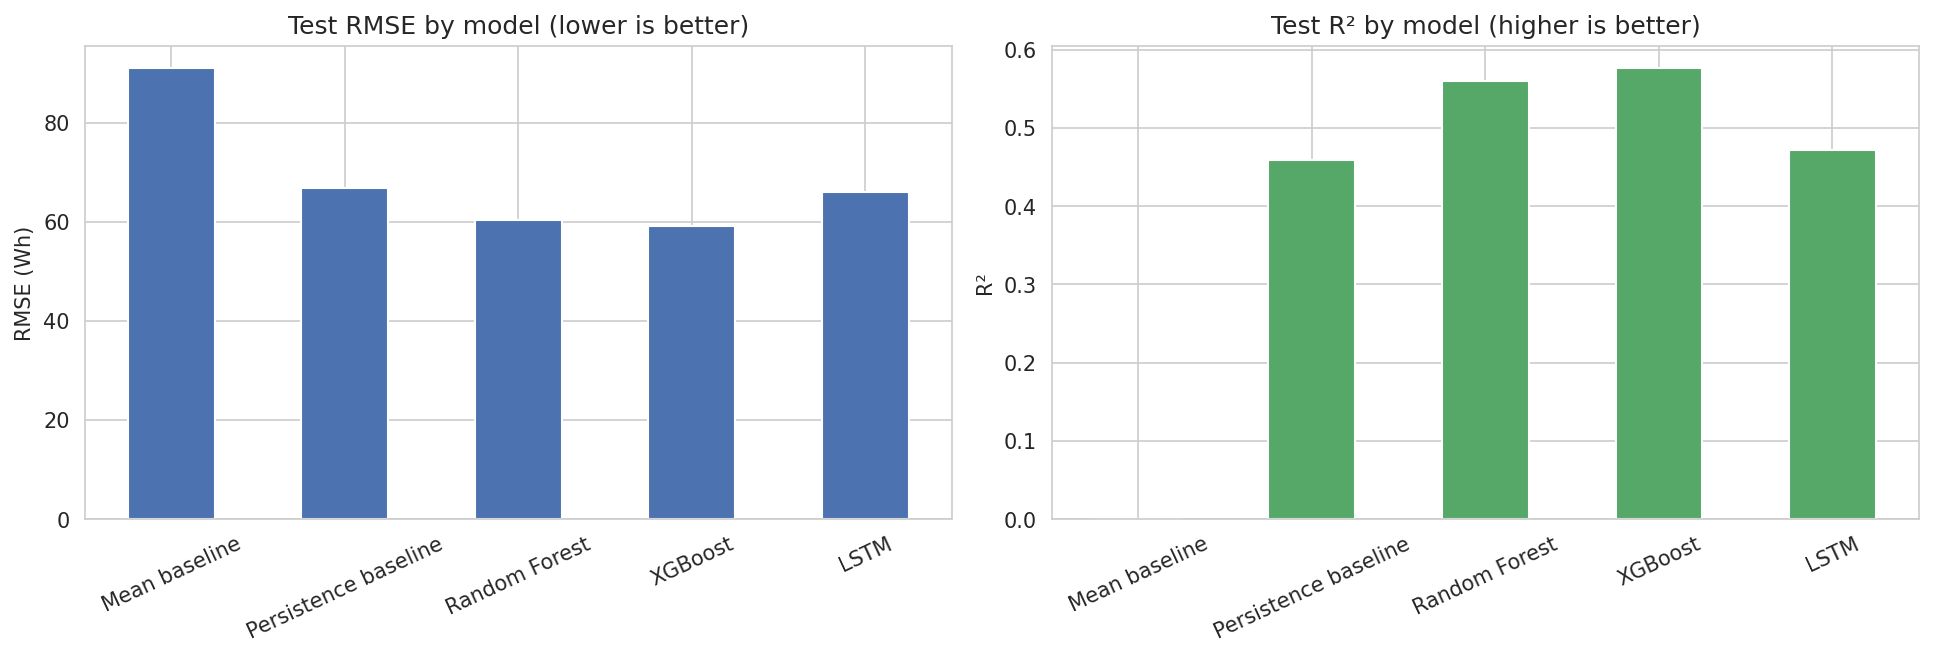

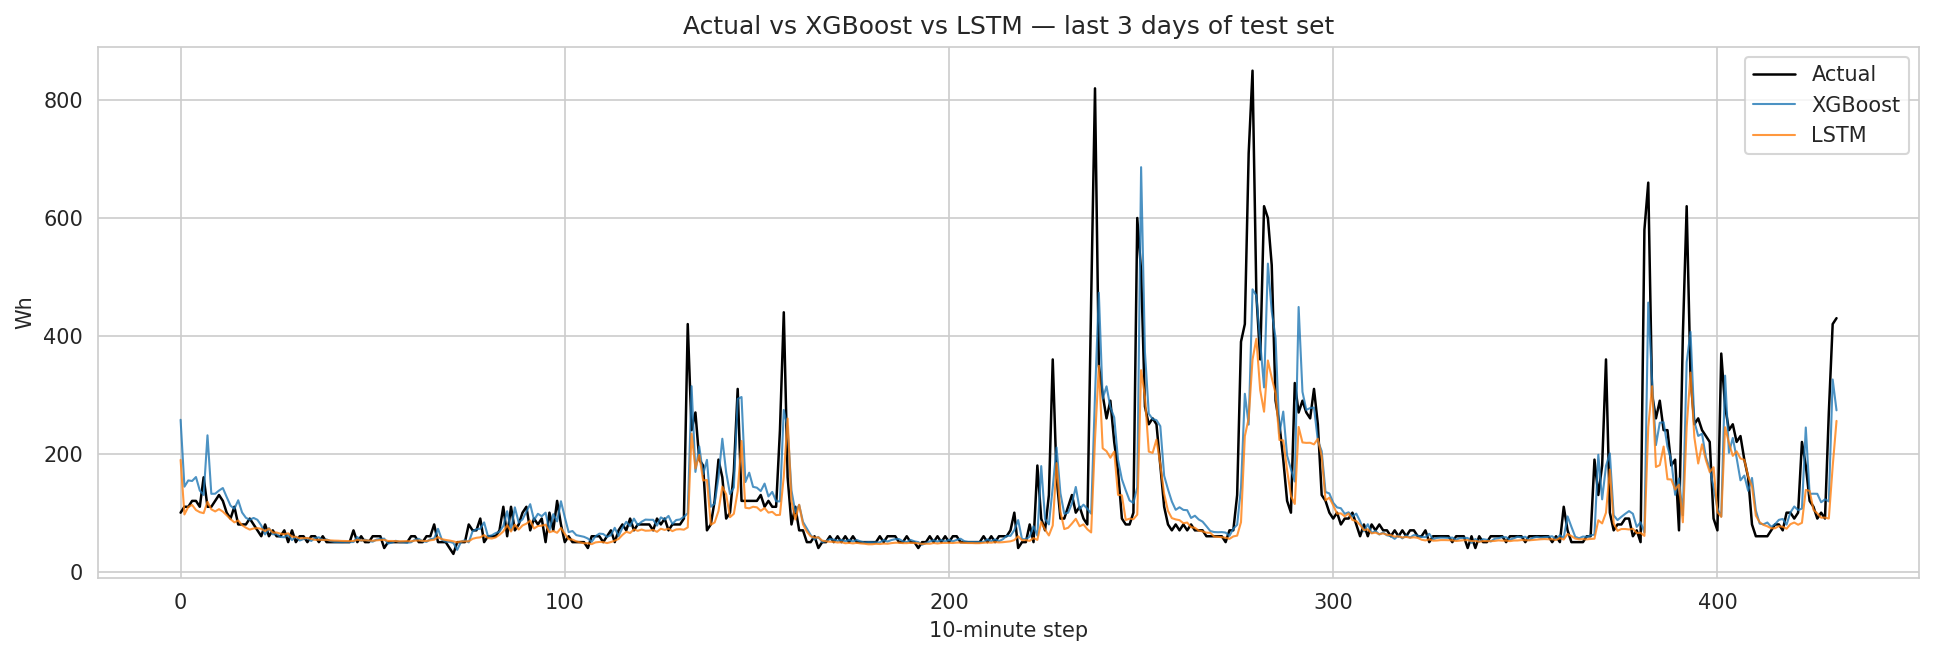

[figs] 3 figures saved and displayed
[save] LSTM model + predictions + final results table written


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> phase3_outputs.zip is downloading.

PHASE 3 COMPLETE.


In [ ]:
"""
============================================================================
 PHASE 3: LSTM (SEQUENTIAL MODEL)
----------------------------------------------------------------------------
 PURPOSE
   Completes Objective 4.2.2 by adding the time-series neural network (LSTM)
   and answers RQ2: does a model that LEARNS temporal structure from the raw
   sequence beat the static tree models that use hand-crafted lag features?
   The LSTM is trained on 24-step (4-hour) sliding windows, with dropout and
   early stopping for regularisation, then evaluated on the SAME held-out test
   set in real Wh and placed in one comparison table with all earlier models.
----------------------------------------------------------------------------
 HOW TO RUN IN COLAB
   1. Run Phase 1 and Phase 2 first in the same notebook.
      (If the runtime was reset, this cell will ask for phase2_outputs.zip.)
   2. A GPU makes training much faster: Runtime -> Change runtime type -> GPU.
   3. PASTE this whole file into a NEW cell (do NOT use !python ...) and run.
----------------------------------------------------------------------------
 FAIRNESS NOTE
   The LSTM receives sequences of the SAME features the trees use, with each
   window ending at the prediction time-step. Giving both model families the
   same information means any performance gap reflects the LSTM's ability to
   model the temporal sequence, not an information advantage.
============================================================================
"""

import os, json, joblib, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow ships with Colab; install quietly only if missing.
try:
    import tensorflow as tf
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
    import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def show_image(path):
    try:
        from IPython.display import Image, display
        display(Image(filename=path))
    except Exception:
        pass

# Reproducibility. (On a GPU small run-to-run variation can still occur; the
# seed keeps it minimal — worth noting in the dissertation.)
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_style("whitegrid")

PROJ = "energy_project"
DATA_DIR, FIG_DIR, ART_DIR = f"{PROJ}/data", f"{PROJ}/figures", f"{PROJ}/artifacts"

# ===========================================================================
# 0. LOAD PHASE 1 DATA + PHASE 2 RESULTS
# ===========================================================================
if not os.path.exists(f"{ART_DIR}/phase2_results.csv"):
    try:
        from google.colab import files
        print(">> Phase 2 outputs not found. Please upload phase2_outputs.zip ...")
        up = files.upload()
        import zipfile
        with zipfile.ZipFile(list(up.keys())[0]) as z:
            z.extractall(PROJ)
    except Exception as e:
        raise FileNotFoundError("Run Phase 1 and Phase 2 first, or upload phase2_outputs.zip") from e

meta = json.load(open(f"{ART_DIR}/meta.json"))
FEATURES   = meta["feature_cols"]
TARGET_LOG = meta["target_log"]
TARGET_RAW = meta["target_raw"]
LOOKBACK   = meta["lookback"]          # 24 steps = 4 hours

prev_results = pd.read_csv(f"{ART_DIR}/phase2_results.csv", index_col=0)
prev_preds   = pd.read_csv(f"{ART_DIR}/phase2_test_predictions.csv")

# Rebuild the FULL ordered, scaled feature matrix by concatenating the splits
# in time order (they were saved chronologically and scaled with the
# train-fit scaler). Building sequences on the full matrix lets the val/test
# windows borrow the immediately preceding rows as context — realistic, and it
# avoids throwing away the first rows of each split.
def load(split):
    return pd.read_csv(f"{DATA_DIR}/{split}.csv")
train, val, test = load("train"), load("val"), load("test")
n_tr, n_va, n_te = len(train), len(val), len(test)

X_all = pd.concat([train[FEATURES], val[FEATURES], test[FEATURES]], ignore_index=True).values.astype("float32")
y_all_log = np.concatenate([train[TARGET_LOG], val[TARGET_LOG], test[TARGET_LOG]]).astype("float32")
y_all_raw = np.concatenate([train[TARGET_RAW], val[TARGET_RAW], test[TARGET_RAW]]).astype("float32")
print(f"[load] full matrix {X_all.shape} | splits: train {n_tr}, val {n_va}, test {n_te}")

# ===========================================================================
# 1. BUILD SEQUENCES
#    For target row i, the input window is rows [i-LOOKBACK+1 .. i] (it ends AT
#    the prediction step, matching the trees' access to current-time features).
#    Each sequence is then assigned to train/val/test by the index of its
#    target row, so there is no shuffling and no leakage across time.
# ===========================================================================
def build(X, y, lookback):
    Xs, ys, idx = [], [], []
    for i in range(lookback - 1, len(X)):
        Xs.append(X[i - lookback + 1 : i + 1]); ys.append(y[i]); idx.append(i)
    return np.asarray(Xs, dtype="float32"), np.asarray(ys, dtype="float32"), np.asarray(idx)

Xseq, yseq_log, idx = build(X_all, y_all_log, LOOKBACK)

tr_mask = idx < n_tr
va_mask = (idx >= n_tr) & (idx < n_tr + n_va)
te_mask = idx >= n_tr + n_va

Xtr, ytr = Xseq[tr_mask], yseq_log[tr_mask]
Xva, yva = Xseq[va_mask], yseq_log[va_mask]
Xte, yte = Xseq[te_mask], yseq_log[te_mask]
yte_raw  = y_all_raw[idx[te_mask]]                  # true Wh for the test windows
n_feat   = Xtr.shape[2]
print(f"[seq] train {Xtr.shape}  val {Xva.shape}  test {Xte.shape}")

# ===========================================================================
# 2. BUILD THE LSTM
#    Two stacked LSTM layers learn short- and longer-range temporal patterns;
#    Dropout after each is the regularisation the proposal names as the
#    mitigation for overfitting. A small Dense head maps to the single output.
# ===========================================================================
model = Sequential([
    Input(shape=(LOOKBACK, n_feat)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),                                       # predicts log1p(Appliances)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

# Early stopping chooses the number of epochs objectively (restores the best
# weights seen on the validation set); LR reduction helps it settle.
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-5),
]

# ===========================================================================
# 3. TRAIN
# ===========================================================================
history = model.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=100, batch_size=64,
    callbacks=callbacks, verbose=1,
)
print(f"[train] stopped after {len(history.history['loss'])} epochs")

# ===========================================================================
# 4. EVALUATE ON TEST  (convert log -> Wh, clip at zero, score in real units)
# ===========================================================================
def to_wh(pred_log):
    return np.clip(np.expm1(pred_log), 0, None)

lstm_pred = to_wh(model.predict(Xte, verbose=0).ravel())
mae  = mean_absolute_error(yte_raw, lstm_pred)
rmse = mean_squared_error(yte_raw, lstm_pred) ** 0.5
r2   = r2_score(yte_raw, lstm_pred)
print(f"\n[LSTM] Test MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

# ===========================================================================
# 5. FINAL COMPARISON TABLE  (all five models)
# ===========================================================================
results = prev_results.copy()
results.loc["LSTM"] = [round(mae, 3), round(rmse, 3), round(r2, 3)]
results.to_csv(f"{ART_DIR}/phase3_results.csv")
print("\n==============  FINAL RESULTS (held-out test set)  ==============")
print(results.to_string())
try:
    from IPython.display import display
    display(results)
except Exception:
    pass

# ===========================================================================
# 6. FIGURES  (saved + shown inline)
# ===========================================================================
# Figure H — training/validation loss curves (shows learning + early stopping).
fig = plt.figure(figsize=(8, 4.5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("LSTM training history (MSE on log target)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.tight_layout()
pH = f"{FIG_DIR}/figH_lstm_training.png"
plt.savefig(pH, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pH)

# Figure I — final model comparison across all five models.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
results["Test RMSE (Wh)"].plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Test RMSE by model (lower is better)", ylabel="RMSE (Wh)")
ax[0].tick_params(axis="x", rotation=25)
results["Test R2"].plot.bar(ax=ax[1], color="#55A868")
ax[1].set(title="Test R\u00b2 by model (higher is better)", ylabel="R\u00b2")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
pI = f"{FIG_DIR}/figI_final_comparison.png"
plt.savefig(pI, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pI)

# Figure J — actual vs the best tree (XGBoost) vs LSTM over the last 3 days.
win = 432
fig = plt.figure(figsize=(13, 4.5))
plt.plot(yte_raw[-win:], label="Actual", color="black", lw=1.2)
if "xgb_pred_Wh" in prev_preds:
    plt.plot(prev_preds["xgb_pred_Wh"].values[-win:], label="XGBoost", lw=1.0, alpha=0.8)
plt.plot(lstm_pred[-win:], label="LSTM", lw=1.0, alpha=0.8)
plt.title("Actual vs XGBoost vs LSTM — last 3 days of test set")
plt.xlabel("10-minute step"); plt.ylabel("Wh"); plt.legend()
plt.tight_layout()
pJ = f"{FIG_DIR}/figJ_actual_vs_pred_lstm.png"
plt.savefig(pJ, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pJ)
print("[figs] 3 figures saved and displayed")

# ===========================================================================
# 7. SAVE MODEL + PREDICTIONS  (Phase 4 SHAP reloads these)
# ===========================================================================
model.save(f"{ART_DIR}/lstm_model.keras")
pd.DataFrame({"actual_Wh": yte_raw, "lstm_pred_Wh": lstm_pred}).to_csv(
    f"{ART_DIR}/phase3_lstm_predictions.csv", index=False)
print("[save] LSTM model + predictions + final results table written")

import shutil
shutil.make_archive("phase3_outputs", "zip", PROJ)
try:
    from google.colab import files
    files.download("phase3_outputs.zip")
    print(">> phase3_outputs.zip is downloading.")
except Exception:
    print(">> Outputs saved in the 'energy_project' folder.")

print("\nPHASE 3 COMPLETE.")

[load] full matrix (19723, 42) | lookback 144 (24 h)
[seq] train (13663, 144, 42)  val (2958, 144, 42)  test (2959, 144, 42)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 144, 64)        │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 144, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,353 (157.63 KB)

 Trainable params: 40,353 (157.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - loss: 2.2884 - mae: 1.0180 - val_loss: 0.3159 - val_mae: 0.3854 - learning_rate: 0.0010
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.4214 - mae: 0.4934 - val_loss: 0.3367 - val_mae: 0.3851 - learning_rate: 0.0010
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - loss: 0.3650 - mae: 0.4558 - val_loss: 0.1981 - val_mae: 0.3098 - learning_rate: 0.0010
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - loss: 0.3184 - mae: 0.4260 - val_loss: 0.1912 - val_mae: 0.3101 - learning_rate: 0.0010
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - loss: 0.2968 - mae: 0.4100 - val_loss: 0.1525 - val_mae: 0.2617 - learning_rate: 0.0010
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - loss: 0.2729 - mae: 0.3925 - val_loss: 0.1894 - val_mae: 0.3088 - learning_rate: 0.0010
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - loss: 0.2639 - mae: 0.3841 - val_loss: 0.1993 - val_mae: 0.3328 - 

,Test MAE (Wh),Test RMSE (Wh),Test R2
Mean baseline,52.834,90.917,-0.000
Persistence baseline,26.756,66.859,0.459
Random Forest,26.676,60.317,0.560
XGBoost,25.426,59.201,0.576
LSTM (4h lookback),25.642,66.055,0.472
LSTM (24h lookback),27.877,68.917,0.425


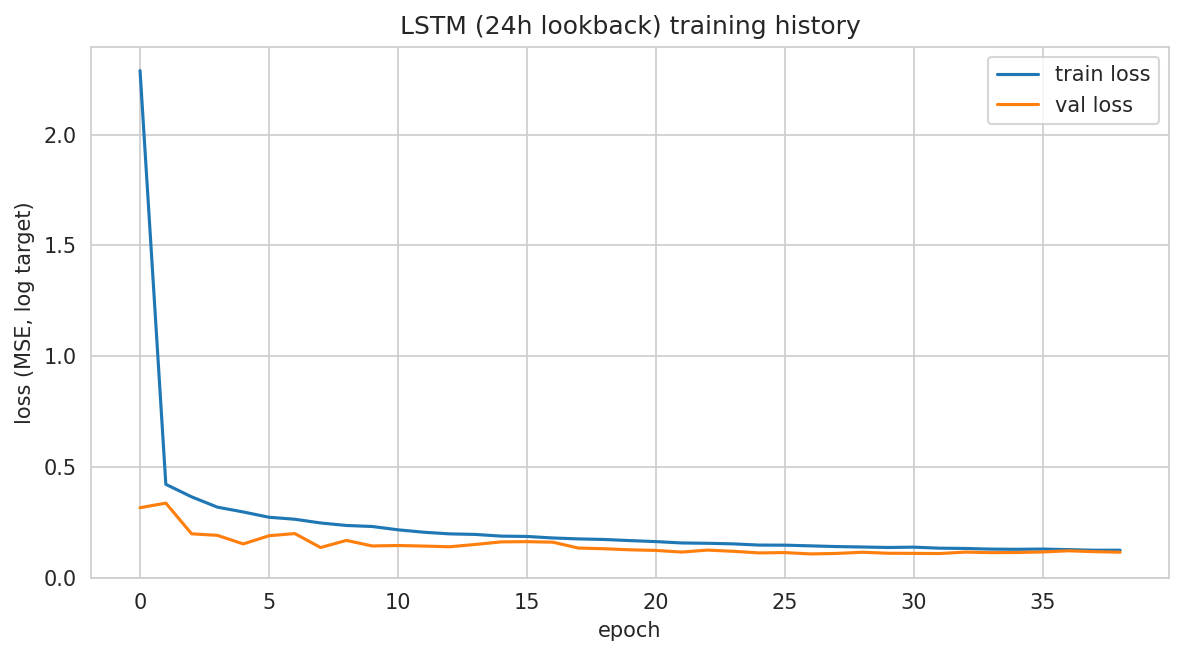

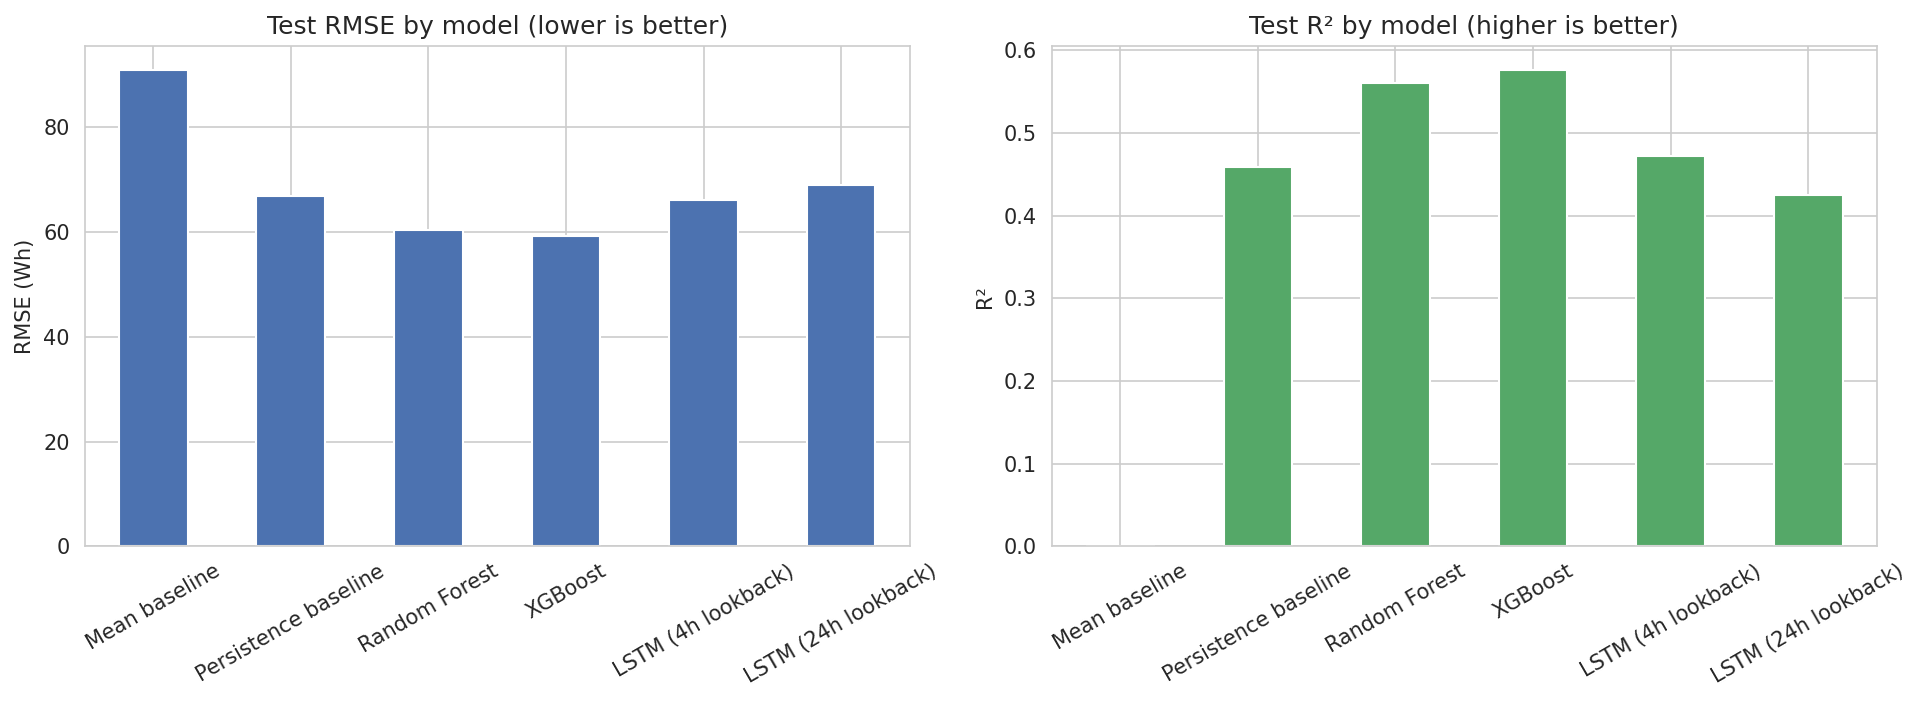

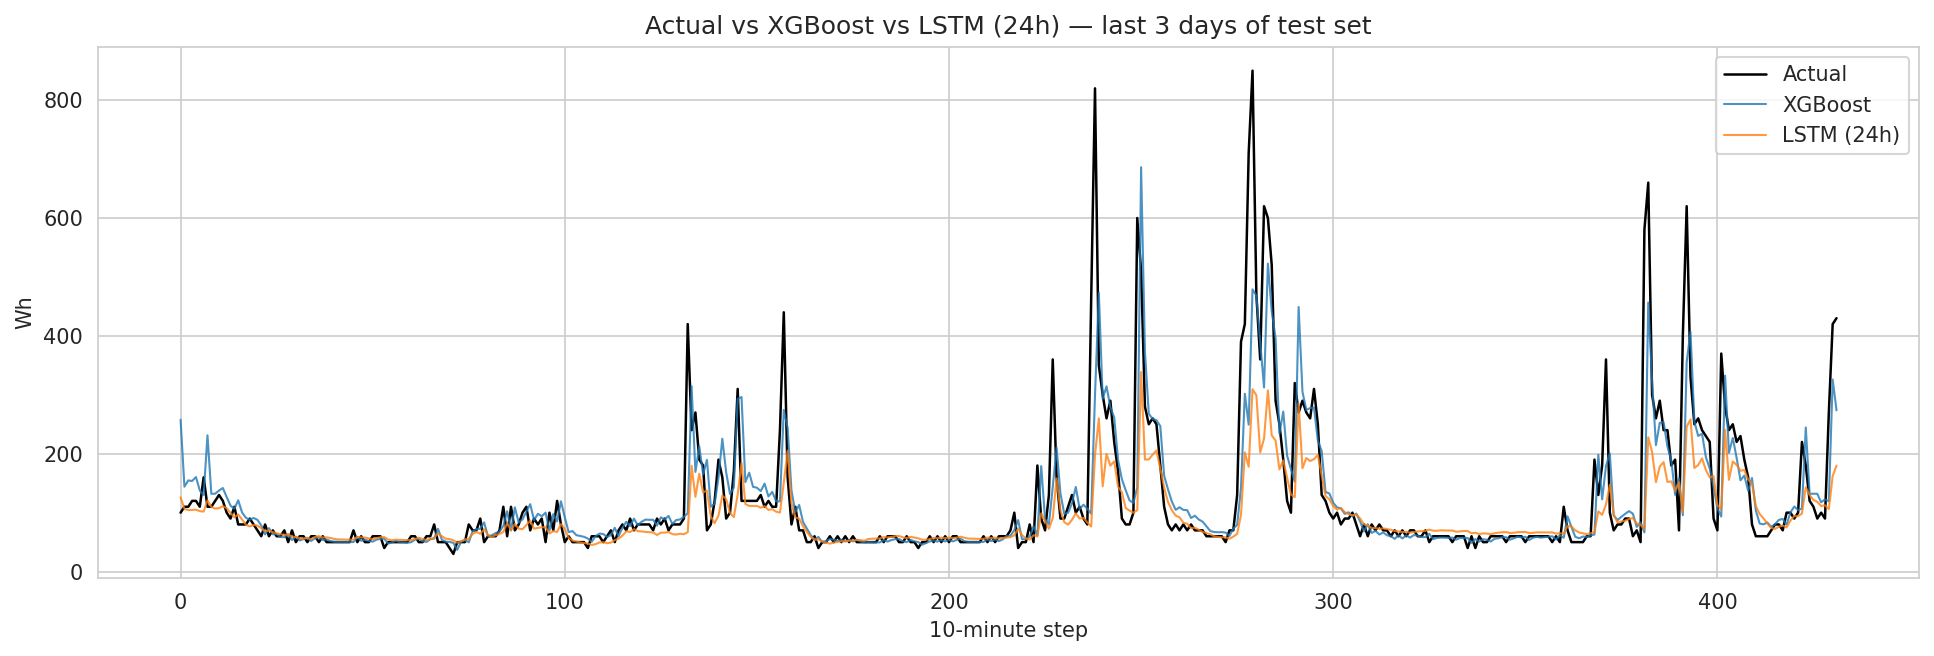

[figs] 3 figures saved and displayed
[save] 24h LSTM model + predictions + results written


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> phase3b_outputs.zip is downloading.

PHASE 3 TUNING PASS COMPLETE.


In [ ]:
"""
============================================================================
 PHASE 3 (TUNING PASS): LSTM with a 24-HOUR LOOKBACK
----------------------------------------------------------------------------
 WHY THIS EXPERIMENT
   The first LSTM used a 4-hour (24-step) window and trailed XGBoost. Appliance
   use has a strong DAILY cycle, which a 4-hour window cannot see in full. This
   pass changes ONE thing only — the lookback is extended to 24 hours
   (144 steps) — so any change in performance is attributable to that window,
   not to other tweaks. Both LSTM variants appear in the final table for a
   like-for-like comparison against the tree models.
----------------------------------------------------------------------------
 HOW TO RUN IN COLAB
   1. Run Phases 1, 2 and 3 first (this reuses their saved outputs).
      If the runtime was reset, this cell will ask for phase3_outputs.zip.
   2. Keep the GPU runtime on (longer windows are heavier).
   3. PASTE into a NEW cell (not !python ...) and run.
============================================================================
"""

import os, json, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import tensorflow as tf
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
    import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def show_image(path):
    try:
        from IPython.display import Image, display
        display(Image(filename=path))
    except Exception:
        pass

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_style("whitegrid")

PROJ = "energy_project"
DATA_DIR, FIG_DIR, ART_DIR = f"{PROJ}/data", f"{PROJ}/figures", f"{PROJ}/artifacts"

LOOKBACK = 144   # <-- the only change: 144 steps x 10 min = 24 hours

# ===========================================================================
# 0. LOAD DATA + PREVIOUS RESULTS
# ===========================================================================
if not os.path.exists(f"{ART_DIR}/phase3_results.csv"):
    try:
        from google.colab import files
        print(">> Phase 3 outputs not found. Please upload phase3_outputs.zip ...")
        up = files.upload()
        import zipfile
        with zipfile.ZipFile(list(up.keys())[0]) as z:
            z.extractall(PROJ)
    except Exception as e:
        raise FileNotFoundError("Run Phases 1-3 first, or upload phase3_outputs.zip") from e

meta = json.load(open(f"{ART_DIR}/meta.json"))
FEATURES   = meta["feature_cols"]
TARGET_LOG = meta["target_log"]
TARGET_RAW = meta["target_raw"]

prev_results = pd.read_csv(f"{ART_DIR}/phase3_results.csv", index_col=0)
prev_preds   = pd.read_csv(f"{ART_DIR}/phase2_test_predictions.csv")

def load(split):
    return pd.read_csv(f"{DATA_DIR}/{split}.csv")
train, val, test = load("train"), load("val"), load("test")
n_tr, n_va, n_te = len(train), len(val), len(test)

X_all = pd.concat([train[FEATURES], val[FEATURES], test[FEATURES]], ignore_index=True).values.astype("float32")
y_all_log = np.concatenate([train[TARGET_LOG], val[TARGET_LOG], test[TARGET_LOG]]).astype("float32")
y_all_raw = np.concatenate([train[TARGET_RAW], val[TARGET_RAW], test[TARGET_RAW]]).astype("float32")
print(f"[load] full matrix {X_all.shape} | lookback {LOOKBACK} (24 h)")

# ===========================================================================
# 1. BUILD 24-HOUR SEQUENCES  (window ends at the prediction step; no leakage)
# ===========================================================================
def build(X, y, lookback):
    Xs, ys, idx = [], [], []
    for i in range(lookback - 1, len(X)):
        Xs.append(X[i - lookback + 1 : i + 1]); ys.append(y[i]); idx.append(i)
    return np.asarray(Xs, dtype="float32"), np.asarray(ys, dtype="float32"), np.asarray(idx)

Xseq, yseq_log, idx = build(X_all, y_all_log, LOOKBACK)
tr_mask = idx < n_tr
va_mask = (idx >= n_tr) & (idx < n_tr + n_va)
te_mask = idx >= n_tr + n_va
Xtr, ytr = Xseq[tr_mask], yseq_log[tr_mask]
Xva, yva = Xseq[va_mask], yseq_log[va_mask]
Xte, yte = Xseq[te_mask], yseq_log[te_mask]
yte_raw  = y_all_raw[idx[te_mask]]
n_feat   = Xtr.shape[2]
print(f"[seq] train {Xtr.shape}  val {Xva.shape}  test {Xte.shape}")

# ===========================================================================
# 2. SAME LSTM ARCHITECTURE (so only the lookback differs)
# ===========================================================================
model = Sequential([
    Input(shape=(LOOKBACK, n_feat)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-5),
]

# ===========================================================================
# 3. TRAIN
# ===========================================================================
history = model.fit(
    Xtr, ytr, validation_data=(Xva, yva),
    epochs=100, batch_size=64, callbacks=callbacks, verbose=1,
)
print(f"[train] stopped after {len(history.history['loss'])} epochs")

# ===========================================================================
# 4. EVALUATE
# ===========================================================================
def to_wh(p): return np.clip(np.expm1(p), 0, None)
pred = to_wh(model.predict(Xte, verbose=0).ravel())
mae  = mean_absolute_error(yte_raw, pred)
rmse = mean_squared_error(yte_raw, pred) ** 0.5
r2   = r2_score(yte_raw, pred)
print(f"\n[LSTM 24h] Test MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

# ===========================================================================
# 5. COMPARISON TABLE  (keep both LSTM variants side by side)
# ===========================================================================
results = prev_results.copy()
if "LSTM" in results.index:
    results = results.rename(index={"LSTM": "LSTM (4h lookback)"})
results.loc["LSTM (24h lookback)"] = [round(mae, 3), round(rmse, 3), round(r2, 3)]
results.to_csv(f"{ART_DIR}/phase3b_results.csv")
print("\n==============  RESULTS WITH BOTH LSTM VARIANTS  ==============")
print(results.to_string())
try:
    from IPython.display import display
    display(results)
except Exception:
    pass

# ===========================================================================
# 6. FIGURES
# ===========================================================================
fig = plt.figure(figsize=(8, 4.5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("LSTM (24h lookback) training history")
plt.xlabel("epoch"); plt.ylabel("loss (MSE, log target)"); plt.legend()
plt.tight_layout()
pH = f"{FIG_DIR}/figH2_lstm24h_training.png"
plt.savefig(pH, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pH)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
results["Test RMSE (Wh)"].plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Test RMSE by model (lower is better)", ylabel="RMSE (Wh)")
ax[0].tick_params(axis="x", rotation=30)
results["Test R2"].plot.bar(ax=ax[1], color="#55A868")
ax[1].set(title="Test R\u00b2 by model (higher is better)", ylabel="R\u00b2")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
pI = f"{FIG_DIR}/figI2_final_comparison.png"
plt.savefig(pI, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pI)

win = 432
fig = plt.figure(figsize=(13, 4.5))
plt.plot(yte_raw[-win:], label="Actual", color="black", lw=1.2)
if "xgb_pred_Wh" in prev_preds:
    plt.plot(prev_preds["xgb_pred_Wh"].values[-win:], label="XGBoost", lw=1.0, alpha=0.8)
plt.plot(pred[-win:], label="LSTM (24h)", lw=1.0, alpha=0.8)
plt.title("Actual vs XGBoost vs LSTM (24h) — last 3 days of test set")
plt.xlabel("10-minute step"); plt.ylabel("Wh"); plt.legend()
plt.tight_layout()
pJ = f"{FIG_DIR}/figJ2_actual_vs_pred_lstm24h.png"
plt.savefig(pJ, dpi=150, bbox_inches="tight"); plt.close(fig); show_image(pJ)
print("[figs] 3 figures saved and displayed")

# ===========================================================================
# 7. SAVE
# ===========================================================================
model.save(f"{ART_DIR}/lstm_model_24h.keras")
pd.DataFrame({"actual_Wh": yte_raw, "lstm24h_pred_Wh": pred}).to_csv(
    f"{ART_DIR}/phase3b_lstm24h_predictions.csv", index=False)
print("[save] 24h LSTM model + predictions + results written")

import shutil
shutil.make_archive("phase3b_outputs", "zip", PROJ)
try:
    from google.colab import files
    files.download("phase3b_outputs.zip")
    print(">> phase3b_outputs.zip is downloading.")
except Exception:
    print(">> Outputs saved in the 'energy_project' folder.")

print("\nPHASE 3 TUNING PASS COMPLETE.")